<h1 align="center">Implement Linear Regression with One Variable on California Housing Dataset</h1>

### *1) Import Libraries and Functions*

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

### *2) Dataframe and setting up dependent variables*

In [69]:
housing = fetch_california_housing()

data = pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"] = housing.target

### *3) Setting up X and y for Gradient Descent*

In [70]:
X = data[['AveRooms']].values
y = data['Price'].values

### *4) Splitting Data into test and train*

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### *5) Feature Scaling*

In [72]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### *6) Gradient Descent*

In [73]:
w = 0
b = 0

learning_rate = 0.01
epochs = 1000
cost_history = []
n = len(X_train_scaled)

for i in range(epochs):
    y_pred = w * X_train_scaled.flatten() + b
    
    cost = (1/(2*n)) * np.sum((y_pred - y_train) ** 2)
    cost_history.append(cost)
    
    dw = (1/n) * np.sum((y_pred - y_train) * X_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if i % 100 == 0:
        print(f"Epoch {i}, Cost = {cost:.4f}")

y_pred_gd = w * X_test_scaled.flatten() + b

Epoch 0, Cost = 2.8149
Epoch 100, Cost = 0.9414
Epoch 200, Cost = 0.6904
Epoch 300, Cost = 0.6568
Epoch 400, Cost = 0.6523
Epoch 500, Cost = 0.6517
Epoch 600, Cost = 0.6516
Epoch 700, Cost = 0.6516
Epoch 800, Cost = 0.6516
Epoch 900, Cost = 0.6516


### *7) Check Metrics of Gradient Descent*

In [74]:
print("Gradient Descent")
print("----------------")
print("Weight:", w)
print("Bias:", b)
print("MSE:", mean_squared_error(y_test, y_pred_gd))
print("R2 Score:", r2_score(y_test, y_pred_gd))

Gradient Descent
----------------
Weight: 0.18323090648660517
Bias: 2.0718574888450205
MSE: 1.292327655590046
R2 Score: 0.013798228607320828


### *8) Normal Equation*

In [75]:
X_train_ne = np.c_[np.ones((len(X_train),1)), X_train]
X_test_ne = np.c_[np.ones((len(X_test),1)), X_test]

theta = np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ y_train
y_pred_ne = X_test_ne @ theta

### *9) Check Metrics of Normal Equation*

In [76]:
print("Normal Equation")
print("----------------")
print("Intercept:", theta[1])
print("Slope:", theta[0])
print("MSE:", mean_squared_error(y_test, y_pred_ne))
print("R2 Score:", r2_score(y_test, y_pred_ne))

Normal Equation
----------------
Intercept: 0.07675558963126736
Slope: 1.6547622685968417
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


### *10) Gradient Descent Cost Convergence Graph*

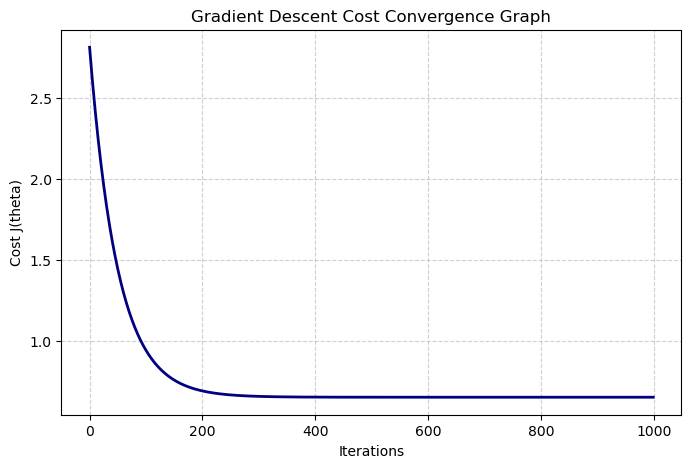

In [77]:
plt.figure(figsize=(8,5))

plt.plot(cost_history, color='navy', linewidth=2)

plt.title('Gradient Descent Cost Convergence Graph')
plt.xlabel('Iterations')
plt.ylabel('Cost J(theta)')
plt.grid(True, linestyle='--',alpha = 0.6)

plt.show()

### *11) Regression Line Visualisation*

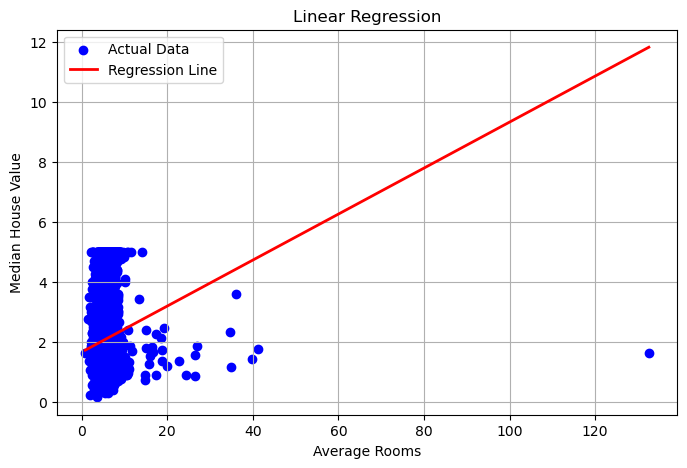

In [79]:
index = np.argsort(X_test.flatten())
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, color = 'blue', label='Actual Data')

plt.plot(
    X_test.flatten()[index],
    y_pred_ne[index],
    color='red',
    linewidth=2,
    label='Regression Line'
)
plt.title("Linear Regression")
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.legend()
plt.grid(True)

plt.show()